# 04 · EDA — 01. Carga, diagnóstico y limpieza

Primer notebook de la fase de análisis exploratorio. Su objetivo es **generar `master_clean.csv`**,
una versión depurada de `master_total.csv` lista para los análisis posteriores (notebooks 04_02–04_05).

## Decisiones de limpieza abordadas

1. **Duplicados puros** (mismo jugador, mismo equipo, misma temporada, filas idénticas).
2. **Salarios anómalos = 0 €** — análisis y tratamiento.
3. **Casos multi-fila** (jugadores con varias filas en una misma temporada por cambios de liga).
4. **Patrón de nulos por columna** — clasificación entre nulos estructurales (por posición) y nulos de cobertura.
5. **Cobertura temporal de variables avanzadas** (xG, xA) — limitación de la fuente desde 22/23.
6. **Optimización de tipos de datos** — corrección de columnas float que son realmente enteras.

⚠️ El criterio general de esta fase es **conservador**: solo se eliminan filas o se imputan valores
cuando hay justificación clara. Las decisiones más complejas (filtrado por minutos, transformación
del target, encoding de categóricas, agregación de multi-fila) se posponen al feature engineering (fase 05).

---

## 1. Imports y carga

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración estética
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT   = Path.cwd().parents[1]
MASTER = ROOT / 'data' / 'master' / 'master_total.csv'
CLEAN  = ROOT / 'data' / 'clean'
CLEAN.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(MASTER, dtype={'season': str})

print(f'✅ Cargado master_total.csv')
print(f'   Filas:    {len(df):,}')
print(f'   Columnas: {df.shape[1]}')

✅ Cargado master_total.csv
   Filas:    20,316
   Columnas: 122


### 1.1 Resumen rápido del dataset

In [19]:
print('=== Tipos de datos ===')
print(df.dtypes.value_counts())

print('\n=== Columnas no numéricas ===')
print(df.select_dtypes(exclude=[np.number]).columns.tolist())

print('\n=== Posiciones ===')
print(df['position'].value_counts(dropna=False))

=== Tipos de datos ===
int64      88
float64    28
object      6
Name: count, dtype: int64

=== Columnas no numéricas ===
['player', 'team', 'country', 'season', 'position', 'nationality']

=== Posiciones ===
position
F      6523
D      6358
M      4183
NaN    1756
K      1496
Name: count, dtype: int64


## 2. Duplicados puros

Filas idénticas a nivel `(player, team, season)`. Estos casos provienen de Capology, donde
en algunas plantillas hay entradas duplicadas que multiplicaron las filas en el merge final.

In [20]:
dup_mask = df.duplicated(subset=['player','team','season'], keep=False)
print(f'Filas en grupos de duplicados: {dup_mask.sum()}')

if dup_mask.sum() > 0:
    print('\n=== Casos detectados ===')
    cols_show = ['player', 'team', 'country', 'season', 'minutesPlayed', 'gross_annual_eur']
    display(df[dup_mask][cols_show].sort_values(['player', 'season']))

Filas en grupos de duplicados: 12

=== Casos detectados ===


,player,team,country,season,minutesPlayed,gross_annual_eur
9734,Ionuț Radu,Inter,italy,2021,135,1850000.0
9735,Ionuț Radu,Inter,italy,2021,135,1850000.0
9736,Ionuț Radu,Inter,italy,2021,135,1850000.0
9737,Ionuț Radu,Inter,italy,2021,135,1850000.0
489,Lys Mousset,Sheffield United,england,2021,298,1506013.0
490,Lys Mousset,Sheffield United,england,2021,298,1506013.0
491,Lys Mousset,Sheffield United,england,2021,298,1506013.0
492,Lys Mousset,Sheffield United,england,2021,298,1506013.0
9688,Vlad Chiricheş,Sassuolo,italy,2021,1841,1480000.0
9689,Vlad Chiricheş,Sassuolo,italy,2021,1841,1480000.0


**Decisión:** se eliminan los duplicados conservando solo la primera aparición de cada combinación
`(player, team, season)`. Como las filas son idénticas en todas las columnas relevantes, esta operación
no introduce sesgo: simplemente corrige un error técnico de la fuente.

In [21]:
filas_antes = len(df)
df = df.drop_duplicates(subset=['player', 'team', 'season'], keep='first').reset_index(drop=True)
filas_despues = len(df)

print(f'Filas antes:    {filas_antes:,}')
print(f'Filas después:  {filas_despues:,}')
print(f'Eliminadas:     {filas_antes - filas_despues}')

Filas antes:    20,316
Filas después:  20,307
Eliminadas:     9


## 3. Salarios anómalos (= 0 €)

Existen registros con `gross_annual_eur = 0`. Se analiza su distribución por liga y temporada
y se decide su tratamiento.

In [22]:
zero = df[df['gross_annual_eur'] == 0]
print(f'Total registros con salario = 0: {len(zero)}')

print('\n=== Distribución por liga × temporada ===')
display(zero.groupby(['country', 'season']).size().unstack(fill_value=0))

Total registros con salario = 0: 80

=== Distribución por liga × temporada ===


season,2021,2122,2223,2324,2425
country,,,,,
england,0,0,1,7,11
france,1,0,3,2,1
germany,0,0,1,2,0
italy,1,36,0,2,2
spain,0,0,3,2,0
turkey,3,0,0,1,1


In [23]:
# Inspección detallada del caso más concentrado: Italia 21/22
zero_it = zero[(zero['country']=='italy') & (zero['season']=='2122')]
print(f'Caso Italia 21/22: {len(zero_it)} jugadores con salario 0')
print('\nPrimeros 10 jugadores afectados:')
display(zero_it[['player','team','minutesPlayed','position']].head(10))

Caso Italia 21/22: 36 jugadores con salario 0

Primeros 10 jugadores afectados:


,player,team,minutesPlayed,position
10223,Boris Radunović,Cagliari,270,K
10370,Giacomo Satalino,Sassuolo,8,K
10371,Davide Marfella,Napoli,10,K
10389,Éderson,Salernitana,1152,M
10451,Gerard Yepes,Sampdoria,17,M
10453,Stefan Strandberg,Salernitana,934,D
10491,Kristjan Asllani,Empoli,1357,M
10501,Nicolò Bertola,Spezia,33,D
10535,Edoardo Bove,Roma,75,M
10536,Nicolò Casale,Hellas Verona,2607,D


**Análisis:** los jugadores con salario 0 son en su mayoría jugadores **cedidos**, cuyo salario lo paga
el club de origen y no aparece en la ficha del club de destino. Esto se intuye porque:

- Son mayoritariamente jugadores con minutos jugados reales (no fantasmas).
- La concentración en Italia 21/22 corresponde a una temporada con muchas cesiones documentadas.

**Decisión:** se convierten los `0` a `NaN`. Razones:

1. Un valor 0 en el target distorsionaría cualquier modelo logarítmico (`log(0) = -∞`).
2. Cero no representa la realidad económica del jugador (sí cobra, pero en otro sitio).
3. Tratarlos como nulos es coherente con el resto de jugadores sin salario disponible.

In [24]:
mask_zero = df['gross_annual_eur'] == 0
df.loc[mask_zero, 'gross_annual_eur'] = np.nan
df.loc[mask_zero, 'gross_weekly_eur'] = np.nan

print(f'✅ Convertidos {mask_zero.sum()} ceros a NaN')
print(f'\nNuevo recuento de nulos en target: {df["gross_annual_eur"].isna().sum():,}')

✅ Convertidos 80 ceros a NaN

Nuevo recuento de nulos en target: 1,844


## 4. Casos multi-fila (jugadores con varias ligas en una misma temporada)

524 jugadores aparecen con más de una fila en la misma temporada por haber jugado en varias ligas
(traspasos, cesiones a mitad de temporada). Estos casos son **información real**, no errores.

In [25]:
grp = df.groupby(['player_id', 'season']).size()
multi = grp[grp > 1]

print(f'Jugadores con >1 fila en una temporada: {len(multi):,}')
print(f'Filas totales afectadas:                {multi.sum():,}')
print(f'\n=== Distribución por nº de filas ===')
print(multi.value_counts().sort_index())

Jugadores con >1 fila en una temporada: 521
Filas totales afectadas:                1,043

=== Distribución por nº de filas ===
2    520
3      1
Name: count, dtype: int64


In [26]:
ej_pid, ej_sea = multi.index[0]
ejemplo = df[(df['player_id']==ej_pid) & (df['season']==ej_sea)]
print(f'Ejemplo: player_id={ej_pid}, season={ej_sea}')
display(ejemplo[['player','team','country','minutesPlayed','goals','gross_annual_eur']])

Ejemplo: player_id=750, season=2122


,player,team,country,minutesPlayed,goals,gross_annual_eur
550,Cristiano Ronaldo,Manchester United,england,2458,18,31023864.0
10733,Cristiano Ronaldo,Juventus,italy,31,0,NaN


**Decisión:** **se conservan todas las filas** en `master_clean.csv`. La agregación se pospone
al feature engineering (fase 05), donde se evaluarán varias estrategias:

- Quedarse solo con la fila del equipo donde el jugador disputó **más minutos**.
- Agregar las stats sumando minutos y promediando ratios.
- Tratar cada fila como una observación independiente (jugador-equipo-temporada).

Mantenerlas todas en esta fase preserva la información completa del dataset y permite analizar
estos casos en el EDA. La decisión final dependerá de la naturaleza de cada modelo.

## 5. Análisis del patrón de nulos

Se clasifican los nulos en dos tipos:
- **Estructurales:** la columna no aplica a ese jugador por su posición (p. ej. `goalsPrevented` en delanteros).
- **De cobertura:** el dato falta por limitaciones de la fuente (p. ej. `gross_annual_eur` en canteranos).

### 5.1 Top columnas con más nulos

In [27]:
nulos_pct = (df.isna().mean() * 100).round(2)
nulos_top = nulos_pct[nulos_pct > 0].sort_values(ascending=False)

print(f'Columnas con al menos un nulo: {len(nulos_top)}')
print('\n=== Top 20 columnas con más nulos ===')
display(nulos_top.head(20).to_frame('% nulos'))

Columnas con al menos un nulo: 12

=== Top 20 columnas con más nulos ===


,% nulos
goalsPrevented,94.26
download_date,84.04
outfielderBlocks,81.34
goalKicks,50.88
ballRecovery,50.87
expectedGoals,44.05
expectedAssists,37.39
gross_weekly_eur,9.08
gross_annual_eur,9.08
position,8.65


### 5.2 Visualización de nulos por columna

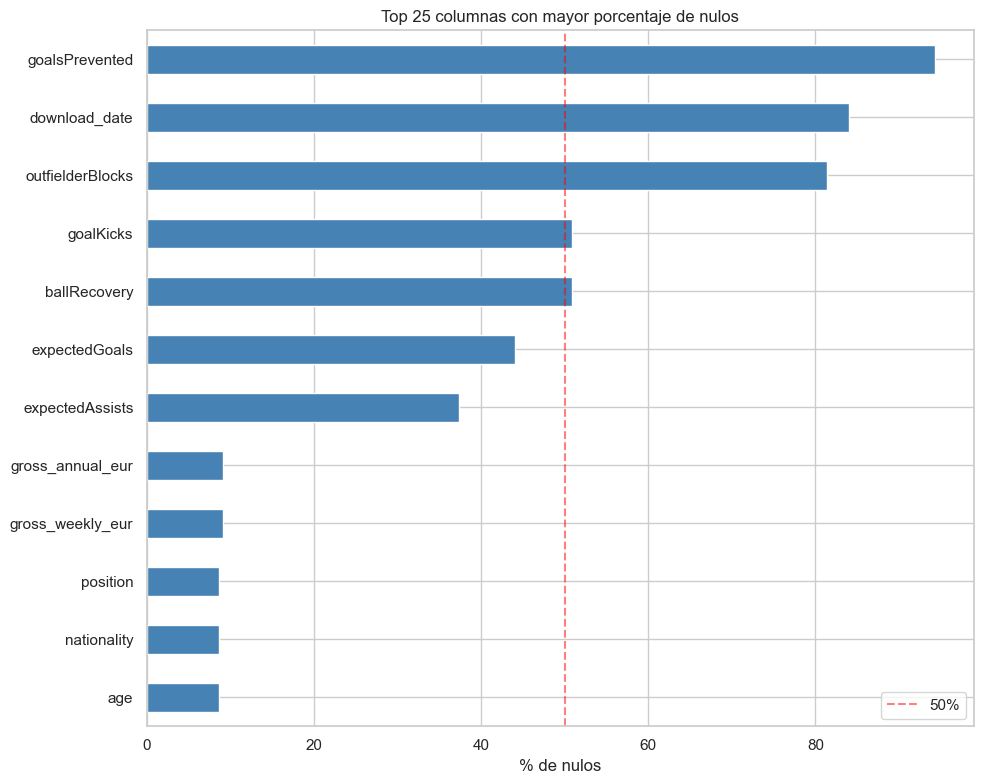

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
nulos_top.head(25).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% de nulos')
ax.set_title('Top 25 columnas con mayor porcentaje de nulos')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 Validación de la hipótesis de nulos estructurales por posición

In [29]:
cols_test = ['goalsPrevented', 'goalKicks', 'outfielderBlocks', 'expectedGoals', 'expectedAssists']

print('=== % de nulos por posición y columna ===')
tabla = df.groupby('position', dropna=False)[cols_test].apply(lambda g: g.isna().mean()*100).round(1)
display(tabla)

=== % de nulos por posición y columna ===


,goalsPrevented,goalKicks,outfielderBlocks,expectedGoals,expectedAssists
position,,,,,
D,99.7,50.9,81.6,40.6,36.8
F,99.7,50.6,81.6,39.1,37.2
K,26.3,52.4,83.2,74.8,39.2
M,99.8,51.3,81.9,39.6,37.2
NaN,99.0,49.5,76.5,59.0,39.1


**Interpretación esperada:**
- `goalsPrevented`, `goalKicks`: nulas en jugadores de campo (D/M/F), llenas solo en porteros (K).
- `outfielderBlocks`: nula en porteros, llena en jugadores de campo.
- `expectedGoals`, `expectedAssists`: tienen nulos repartidos por todas las posiciones, lo que sugiere
  que son nulos de cobertura, no estructurales (ver sección 6).

### 5.4 Tratamiento de nulos estructurales por posición

Solo se imputan los nulos que sean **demostrablemente estructurales**. No se imputan ciegamente
todos los nulos.

| Tipo de nulo | Columnas | Tratamiento |
|---|---|---|
| **Estructural por posición** | `goalsPrevented`, `goalKicks` | Imputar a 0 en no porteros |
| **Estructural por posición** | `outfielderBlocks` | Imputar a 0 en porteros |
| **Cobertura temporal** | `expectedGoals`, `expectedAssists` | Mantener NaN (ver sección 6) |
| **Target salarial** | `gross_annual_eur`, `gross_weekly_eur` | Mantener NaN (filtrado en 05_fe) |
| **Trazabilidad** | `download_date` | Eliminar (solo informativa para snapshots) |

In [30]:
# Imputación estructural por posición
no_portero = df['position'].isin(['D', 'M', 'F'])
for col in ['goalsPrevented', 'goalKicks']:
    if col in df.columns:
        antes = df[col].isna().sum()
        df.loc[no_portero & df[col].isna(), col] = 0
        despues = df[col].isna().sum()
        print(f'{col}: {antes:,} → {despues:,} nulos (imputados {antes-despues:,} a 0 en no porteros)')

portero = df['position'] == 'K'
if 'outfielderBlocks' in df.columns:
    antes = df['outfielderBlocks'].isna().sum()
    df.loc[portero & df['outfielderBlocks'].isna(), 'outfielderBlocks'] = 0
    despues = df['outfielderBlocks'].isna().sum()
    print(f'outfielderBlocks: {antes:,} → {despues:,} nulos (imputados {antes-despues:,} a 0 en porteros)')

goalsPrevented: 19,141 → 2,131 nulos (imputados 17,010 a 0 en no porteros)
goalKicks: 10,332 → 1,652 nulos (imputados 8,680 a 0 en no porteros)
outfielderBlocks: 16,517 → 15,275 nulos (imputados 1,242 a 0 en porteros)


In [31]:
# Eliminación de columna de trazabilidad
if 'download_date' in df.columns:
    df = df.drop(columns=['download_date'])
    print('✅ Columna download_date eliminada')

✅ Columna download_date eliminada


## 6. Cobertura temporal de variables avanzadas (xG, xA)

Las métricas `expectedGoals` (xG) y `expectedAssists` (xA) son productos analíticos calculados a partir
de modelos sobre datos posicionales (event-tracking). Sofascore comenzó a publicarlas a partir de la
**temporada 22/23**, por lo que están sistemáticamente ausentes en 20/21 y 21/22.

Esto es una **limitación temporal del dataset**, no un error de pipeline. No se imputa: hacerlo
inventaría información que en su momento no existía como tecnología.

In [32]:
# Cobertura por temporada
print('=== Cobertura xG y xA por temporada ===')
cobertura_xg = pd.DataFrame({
    'expectedGoals (% no nulo)':   df.groupby('season')['expectedGoals'].apply(lambda s: s.notna().mean()*100).round(1),
    'expectedAssists (% no nulo)': df.groupby('season')['expectedAssists'].apply(lambda s: s.notna().mean()*100).round(1),
})
display(cobertura_xg)

=== Cobertura xG y xA por temporada ===


,expectedGoals (% no nulo),expectedAssists (% no nulo)
season,,
2021,0.0,0.0
2122,0.0,0.0
2223,82.7,82.7
2324,92.0,99.3
2425,81.3,99.0
2526,83.0,98.9


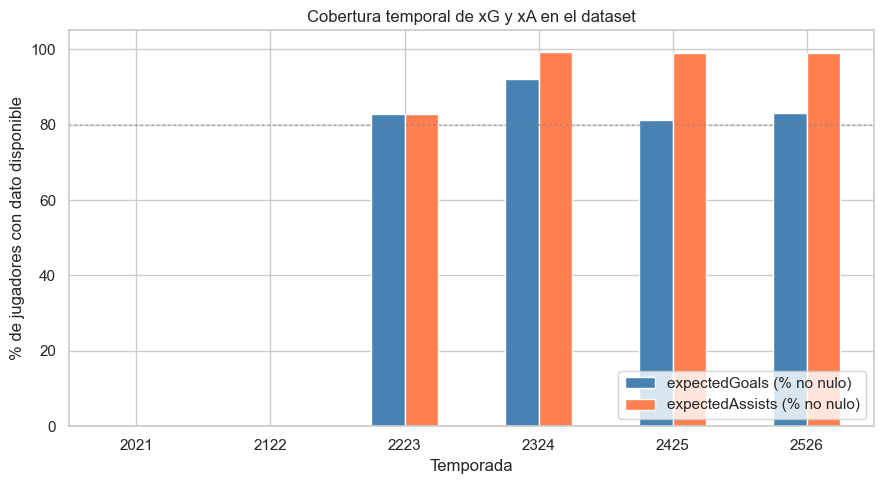

In [33]:
# Visualización
fig, ax = plt.subplots(figsize=(9, 5))
cobertura_xg.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_ylabel('% de jugadores con dato disponible')
ax.set_xlabel('Temporada')
ax.set_title('Cobertura temporal de xG y xA en el dataset')
ax.set_ylim(0, 105)
ax.axhline(y=80, color='gray', linestyle=':', alpha=0.5)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Implicación para el modelado:** en la fase de ML será necesario decidir entre dos estrategias:

- **Estrategia A:** restringir el modelo a las temporadas 22/23–24/25 (con xG/xA disponibles), perdiendo
  ~30% del volumen de datos pero ganando dos features potencialmente muy predictivas.
- **Estrategia B:** entrenar con las 5 temporadas completas excluyendo xG/xA del conjunto de features.

Probablemente convenga **probar ambas variantes y comparar métricas** en la fase 06.

## 7. Optimización de tipos de datos

Algunas columnas se cargan como `float64` simplemente porque tienen NaN, pero sus valores reales
son siempre enteros. Esto genera ruido visual al inspeccionar el dataset (`3.0` en lugar de `3`)
y consume más memoria de la necesaria.

Estrategia:
- **`int` puro:** columnas con ≤1 NaN. Imputamos a 0 y convertimos.
- **`Int64` (entero nullable de pandas):** columnas con más NaN. Permite mantener NaN y mostrar enteros.
- **`float`:** se mantiene en columnas con decimales reales (ratings, percentages, salarios).

In [34]:
# 7.1 Identificar columnas float que son realmente enteras
float_cols = df.select_dtypes(include=['float64']).columns.tolist()

cols_int_puras = []
cols_int_nullable = []
cols_float_reales = []

for col in float_cols:
    s = df[col].dropna()
    if len(s) == 0:
        continue
    es_entero = (s == s.astype(int)).all()
    n_nulos   = df[col].isna().sum()
    if es_entero:
        if n_nulos <= 1:
            cols_int_puras.append((col, n_nulos))
        else:
            cols_int_nullable.append((col, n_nulos))
    else:
        cols_float_reales.append(col)

print(f'Columnas a convertir a int puro: {len(cols_int_puras)}')
for c, n in cols_int_puras: print(f'   {c} (nulos: {n})')

print(f'\nColumnas a convertir a Int64 (nullable): {len(cols_int_nullable)}')
for c, n in cols_int_nullable: print(f'   {c} (nulos: {n})')

print(f'\nColumnas float legítimas: {len(cols_float_reales)}')
for c in cols_float_reales: print(f'   {c}')

Columnas a convertir a int puro: 4
   ownGoals (nulos: 1)
   penaltyGoals (nulos: 1)
   redCards (nulos: 1)
   yellowRedCards (nulos: 1)

Columnas a convertir a Int64 (nullable): 6
   ballRecovery (nulos: 10331)
   goalKicks (nulos: 1652)
   outfielderBlocks (nulos: 15275)
   gross_weekly_eur (nulos: 1844)
   gross_annual_eur (nulos: 1844)
   age (nulos: 1756)

Columnas float legítimas: 17
   rating
   expectedGoals
   expectedAssists
   accurateCrossesPercentage
   accurateLongBallsPercentage
   accuratePassesPercentage
   aerialDuelsWonPercentage
   goalConversionPercentage
   goalsPrevented
   groundDuelsWonPercentage
   penaltyConversion
   scoringFrequency
   setPieceConversion
   successfulDribblesPercentage
   tacklesWonPercentage
   totalDuelsWonPercentage
   totalRating


### 7.2 Aplicar conversiones

⚠️ Los **salarios (`gross_annual_eur`, `gross_weekly_eur`)** se mantienen como `float` aunque sus valores
sean enteros, porque sufrirán transformación logarítmica en la fase 05.

⚠️ La **edad (`age`)** se convierte a `Int64` para preservar los NaN de jugadores sin salario.

In [35]:
# Salarios: forzar permanencia como float
EXCLUIR_DE_CONVERSION = {'gross_annual_eur', 'gross_weekly_eur'}

# Conversión a int puro (con imputación a 0 del único nulo)
for col, _ in cols_int_puras:
    if col in EXCLUIR_DE_CONVERSION:
        continue
    df[col] = df[col].fillna(0).astype('int64')

# Conversión a Int64 nullable
for col, _ in cols_int_nullable:
    if col in EXCLUIR_DE_CONVERSION:
        continue
    df[col] = df[col].astype('Int64')

print('✅ Conversiones aplicadas')
print('\n=== Tipos resultantes (resumen) ===')
print(df.dtypes.value_counts())

✅ Conversiones aplicadas

=== Tipos resultantes (resumen) ===
int64      92
float64    19
object      6
Int64       4
Name: count, dtype: int64


## 8. Resumen final del dataset limpio

In [36]:
print(f'=== master_clean ===')
print(f'Filas:                   {len(df):,}')
print(f'Columnas:                {df.shape[1]}')
print(f'Jugadores únicos:        {df["player_id"].nunique():,}')
print(f'Equipos únicos:          {df["team"].nunique()}')
print(f'Cobertura salarial:      {df["gross_annual_eur"].notna().mean()*100:.1f}%')
print(f'Nulos totales restantes: {df.isna().sum().sum():,}')

=== master_clean ===
Filas:                   20,307
Columnas:                121
Jugadores únicos:        7,759
Equipos únicos:          171
Cobertura salarial:      90.9%
Nulos totales restantes: 54,883


In [37]:
# Cobertura por liga × temporada (post-limpieza)
cobertura = (
    df.groupby(['country','season'])
    .agg(total=('player','size'),
         con_salario=('gross_annual_eur', lambda s: s.notna().sum()))
)
cobertura['pct'] = (cobertura['con_salario'] / cobertura['total'] * 100).round(1)

print('=== Cobertura % por liga × temporada (post-limpieza) ===')
display(cobertura['pct'].unstack(level='season'))

=== Cobertura % por liga × temporada (post-limpieza) ===


season,2021,2122,2223,2324,2425,2526
country,,,,,,
england,93.9,92.6,93.5,89.8,93.8,93.7
france,87.3,89.7,89.4,89.0,87.5,83.8
germany,94.8,95.1,94.9,93.5,97.3,92.5
italy,93.6,86.2,96.0,93.7,94.0,91.1
spain,87.4,88.7,87.0,87.1,87.8,85.3
turkey,95.2,88.7,92.0,95.3,91.7,82.6


## 9. Guardado de `master_clean.csv`

Se guarda en `data/clean/master_clean.csv`. La estructura final del directorio `data/` queda así,
con cada subcarpeta correspondiendo a una fase del pipeline:

```
data/
├── raw/        → datos originales (output de fase 01)
├── processed/  → datos limpios por fuente (output de fase 02)
├── master/     → tablas integradas Sofascore + Capology (output de fase 03)
└── clean/      → dataset analítico depurado (output de fase 04)
```

In [38]:
nombre_salida = 'master_clean.csv'
ruta_salida   = CLEAN / nombre_salida
df.to_csv(ruta_salida, index=False)

print(f'✅ Guardado: {ruta_salida}')
print(f'   Filas:    {len(df):,}')
print(f'   Columnas: {df.shape[1]}')

✅ Guardado: d:\USER\Desktop\TFM\data\clean\master_clean.csv
   Filas:    20,307
   Columnas: 121
